Retention & Engagement Analytics for Gen-Z OTT Users
# Business Problem:
Gen-Z audiences increasingly consume short-form, algorithm-driven content across platforms such as YouTube Shorts and Instagram Reels. Despite increasing investments in premium content, OTT platforms continue facing challenges in sustaining long-term engagement and retention.
This project aims to analyze engagement patterns, retention drivers, churn
signals, and personalization opportunities using product analytics and machine learning techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded= files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [4]:
df= pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
df.shape


(8807, 12)

In [7]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

,0
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


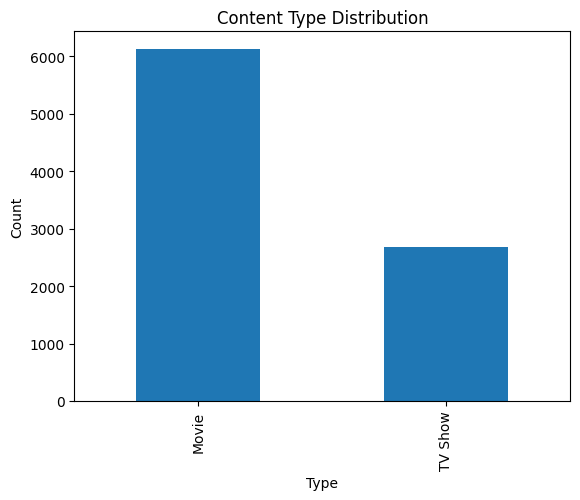

In [15]:

df['type'].value_counts().plot(kind='bar')

plt.title("Content Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

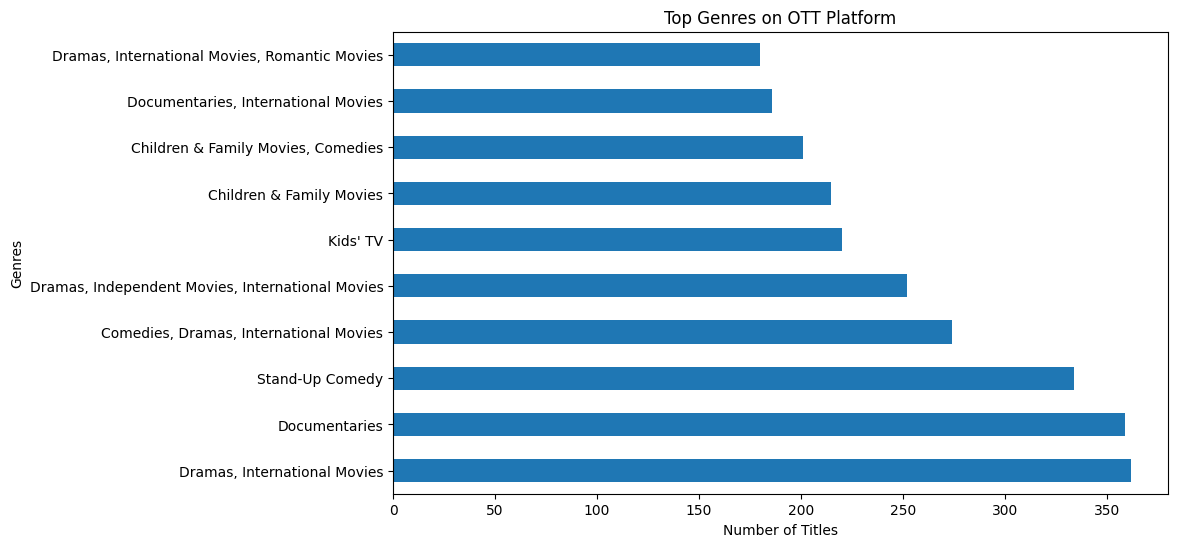

In [16]:
df['listed_in'].value_counts().head(10).plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Top Genres on OTT Platform")
plt.xlabel("Number of Titles")
plt.ylabel("Genres")

plt.show()

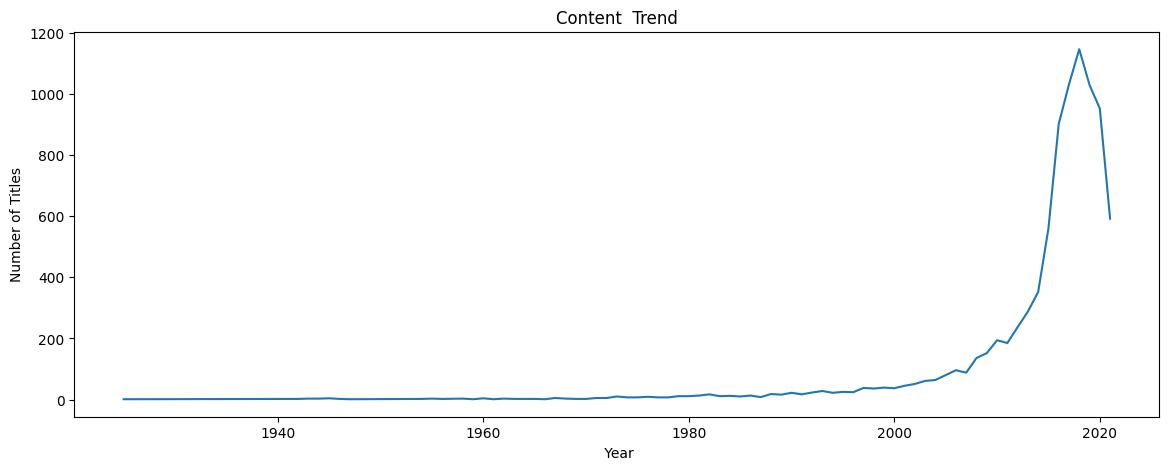

In [18]:
release_trend = df['release_year'].value_counts().sort_index()

release_trend.tail(20)
release_trend.plot(figsize=(14,5))

plt.title("Content  Trend")
plt.xlabel(" Year")
plt.ylabel("Number of Titles")

plt.show()


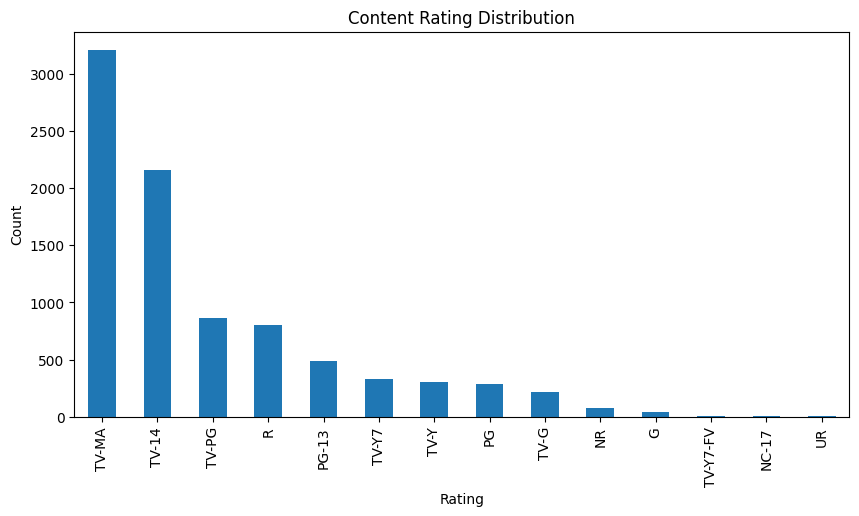

In [21]:
# R

invalid_ratings = ['74 min', '84 min', '66 min']

df = df[~df['rating'].isin(invalid_ratings)]
df['rating'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Content Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

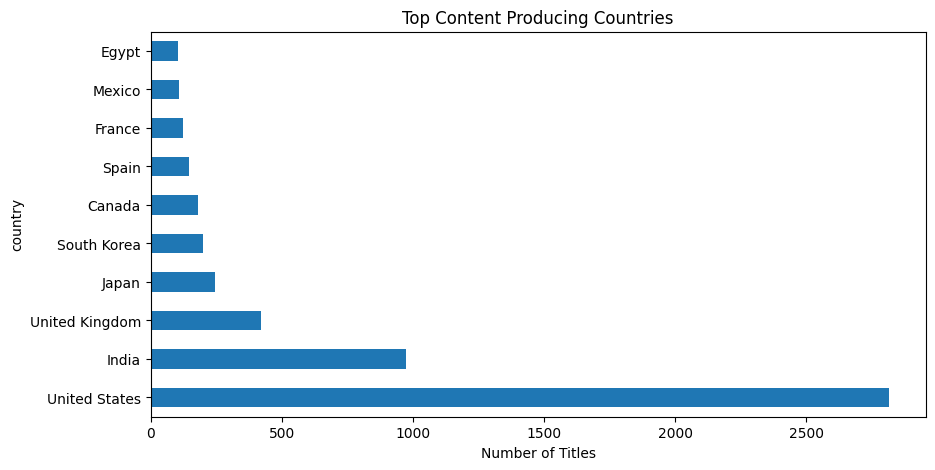

In [23]:
df['country'].value_counts().head(10)
df['country'].value_counts().head(10).plot(
    kind='barh',
    figsize=(10,5)
)

plt.title("Top Content Producing Countries")
plt.xlabel("Number of Titles")

plt.show()

In [24]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration_int'] = (
    movies['duration']
    .str.replace(' min', '', regex=False)
    .astype(int)
)

movies['duration_int'].describe()

,duration_int
count,6128.000000
mean,99.577187
std,28.290593
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


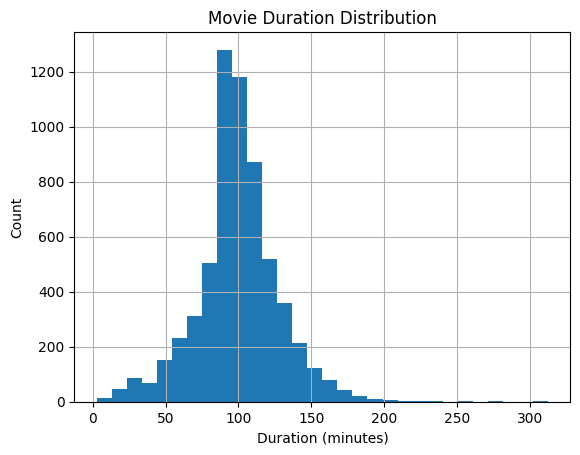

In [25]:
movies['duration_int'].hist(bins=30)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")

plt.show()

# Observation
- TV dramas and international TV content dominate the platform.
- Mature content ratings such as TV-MA appear frequently.
- Content additions increased significantly after 2015.
- Movie durations are concentrated around 90–120 minutes.
- The United States and India contribute a major portion of titles.

In [26]:
#Data cleaning and feature engg

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:")
print(df.shape)

Dataset Shape After Removing Duplicates:
(8804, 12)


In [27]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,0


In [30]:
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')

In [32]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

df['date_added'].head()

,date_added
0,2021-09-25
1,2021-09-24
2,2021-09-24
3,2021-09-24
4,2021-09-24


In [33]:
df['date_added'].isnull().sum()

np.int64(98)

for retention vs freshness analysis

In [34]:
current_year = 2026

df['content_age'] = current_year - df['release_year']

df[['title', 'release_year', 'content_age']].head()

,title,release_year,content_age
0,Dick Johnson Is Dead,2020,6
1,Blood & Water,2021,5
2,Ganglands,2021,5
3,Jailbirds New Orleans,2021,5
4,Kota Factory,2021,5


preferences and binge behaviours

In [35]:
mature_ratings = ['TV-MA', 'R', 'NC-17']

df['is_mature'] = df['rating'].isin(mature_ratings)

df[['title', 'rating', 'is_mature']].head()

,title,rating,is_mature
0,Dick Johnson Is Dead,PG-13,False
1,Blood & Water,TV-MA,True
2,Ganglands,TV-MA,True
3,Jailbirds New Orleans,TV-MA,True
4,Kota Factory,TV-MA,True


In [36]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration_int'] = (
    movies['duration']
    .str.replace(' min', '', regex=False)
)

movies['duration_int'] = pd.to_numeric(
    movies['duration_int'],
    errors='coerce'
)

movies[['title', 'duration', 'duration_int']].head()

,title,duration,duration_int
0,Dick Johnson Is Dead,90 min,90
6,My Little Pony: A New Generation,91 min,91
7,Sankofa,125 min,125
9,The Starling,104 min,104
12,Je Suis Karl,127 min,127


In [37]:
df['primary_genre'] = df['listed_in'].apply(
    lambda x: x.split(',')[0]
)

df[['title', 'listed_in', 'primary_genre']].head()

,title,listed_in,primary_genre
0,Dick Johnson Is Dead,Documentaries,Documentaries
1,Blood & Water,"International TV Shows, TV Dramas, TV Mysteries",International TV Shows
2,Ganglands,"Crime TV Shows, International TV Shows, TV Act...",Crime TV Shows
3,Jailbirds New Orleans,"Docuseries, Reality TV",Docuseries
4,Kota Factory,"International TV Shows, Romantic TV Shows, TV ...",International TV Shows




movies → shorter engagement



TV shows → binge engagement

In [38]:
df['content_category'] = np.where(
    df['type'] == 'Movie',
    'Short-form',
    'Binge-worthy'
)

df[['title', 'type', 'content_category']].head()

,title,type,content_category
0,Dick Johnson Is Dead,Movie,Short-form
1,Blood & Water,TV Show,Binge-worthy
2,Ganglands,TV Show,Binge-worthy
3,Jailbirds New Orleans,TV Show,Binge-worthy
4,Kota Factory,TV Show,Binge-worthy


In [39]:
df['release_decade'] = (
    df['release_year'] // 10
) * 10

df[['title', 'release_year', 'release_decade']].head()

,title,release_year,release_decade
0,Dick Johnson Is Dead,2020,2020
1,Blood & Water,2021,2020
2,Ganglands,2021,2020
3,Jailbirds New Orleans,2021,2020
4,Kota Factory,2021,2020


now checking the altered dataset

In [40]:
df.head(


)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,content_age,is_mature,primary_genre,content_category,release_decade
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",6,False,Documentaries,Short-form,2020
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",5,True,International TV Shows,Binge-worthy,2020
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,5,True,Crime TV Shows,Binge-worthy,2020
3,s4,TV Show,Jailbirds New Orleans,Unknown,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",5,True,Docuseries,Binge-worthy,2020
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,5,True,International TV Shows,Binge-worthy,2020


In [41]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'content_age', 'is_mature', 'primary_genre', 'content_category',
       'release_decade'],
      dtype='object')

In [42]:
df.to_csv('engineered_ott_content.csv', index=False)

print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.


Ott data was transformend into a dataset for pms

In [44]:
#user simulation
num_users = 5000

users = pd.DataFrame({
    'user_id': range(1, num_users + 1),

    'age_group': np.random.choice(
        ['18-21', '22-25', '26-30'],
        num_users,
        p=[0.5, 0.35, 0.15]
    ),

    'subscription_type': np.random.choice(
        ['Free', 'Basic', 'Premium'],
        num_users,
        p=[0.2, 0.5, 0.3]
    ),

    'preferred_device': np.random.choice(
        ['Mobile', 'Laptop', 'TV'],
        num_users,
        p=[0.6, 0.25, 0.15]
    ),

    'user_persona': np.random.choice(
        ['Casual Scroller', 'Weekend Binger', 'Premium Loyalist'],
        num_users,
        p=[0.45, 0.4, 0.15]
    )
})

users.head()


,user_id,age_group,subscription_type,preferred_device,user_persona
0,1,18-21,Basic,Laptop,Casual Scroller
1,2,18-21,Premium,Mobile,Casual Scroller
2,3,18-21,Premium,TV,Casual Scroller
3,4,22-25,Basic,Mobile,Casual Scroller
4,5,26-30,Basic,Mobile,Casual Scroller


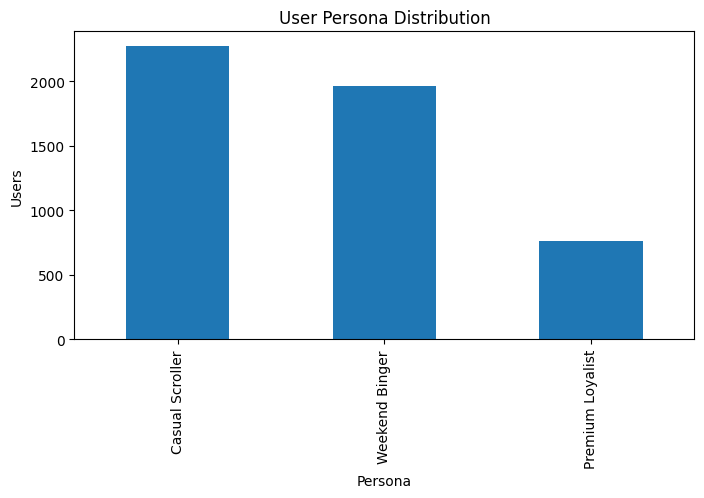

In [46]:
#vizualization of user data

users['user_persona'].value_counts().plot(
    kind='bar',
    figsize=(8,4
             )
)

plt.title("User Persona Distribution")
plt.xlabel("Persona")
plt.ylabel("Users")

plt.show()

In [48]:
#stimulating viewing sessions
watch_history = pd.DataFrame({

    'user_id': np.random.choice(
        users['user_id'],
        50000
    ),

    'content_id': np.random.choice(
        df['show_id'],
        50000
    ),

    'watch_minutes': np.random.randint(
        5,
        180,
        50000
    ),

    'session_date': pd.to_datetime(
        np.random.choice(
            pd.date_range(
                '2025-01-01',
                '2025-12-31'
            ),
            50000
        )
    )
})

watch_history.head()

,user_id,content_id,watch_minutes,session_date
0,2890,s2788,70,2025-01-04
1,1614,s4198,38,2025-01-23
2,2541,s4847,55,2025-01-26
3,4609,s8060,102,2025-08-20
4,4527,s874,149,2025-10-06


In [49]:
#binge watch flag
watch_history['is_binge'] = np.where(
    watch_history['watch_minutes'] > 120,
    1,
    0
)

watch_history.head()

,user_id,content_id,watch_minutes,session_date,is_binge
0,2890,s2788,70,2025-01-04,0
1,1614,s4198,38,2025-01-23,0
2,2541,s4847,55,2025-01-26,0
3,4609,s8060,102,2025-08-20,0
4,4527,s874,149,2025-10-06,1


In [50]:
watch_history = watch_history.merge(
    df[
        [
            'show_id',
            'primary_genre',
            'content_category',
            'is_mature'
        ]
    ],
    left_on='content_id',
    right_on='show_id',
    how='left'
)

watch_history.head()

,user_id,content_id,watch_minutes,session_date,is_binge,show_id,primary_genre,content_category,is_mature
0,2890,s2788,70,2025-01-04,0,s2788,Kids' TV,Binge-worthy,False
1,1614,s4198,38,2025-01-23,0,s4198,Dramas,Short-form,True
2,2541,s4847,55,2025-01-26,0,s4847,Stand-Up Comedy & Talk Shows,Binge-worthy,True
3,4609,s8060,102,2025-08-20,0,s8060,Dramas,Short-form,False
4,4527,s874,149,2025-10-06,1,s874,Dramas,Short-form,True


In [51]:
watch_history = watch_history.merge(
    users,
    on='user_id',
    how='left'
)

watch_history.head()

,user_id,content_id,watch_minutes,session_date,is_binge,show_id,primary_genre,content_category,is_mature,age_group,subscription_type,preferred_device,user_persona
0,2890,s2788,70,2025-01-04,0,s2788,Kids' TV,Binge-worthy,False,18-21,Premium,Mobile,Weekend Binger
1,1614,s4198,38,2025-01-23,0,s4198,Dramas,Short-form,True,22-25,Basic,TV,Casual Scroller
2,2541,s4847,55,2025-01-26,0,s4847,Stand-Up Comedy & Talk Shows,Binge-worthy,True,18-21,Basic,Mobile,Weekend Binger
3,4609,s8060,102,2025-08-20,0,s8060,Dramas,Short-form,False,18-21,Free,Laptop,Weekend Binger
4,4527,s874,149,2025-10-06,1,s874,Dramas,Short-form,True,26-30,Basic,Mobile,Premium Loyalist


In [53]:
watch_history.shape
watch_history.columns

Index(['user_id', 'content_id', 'watch_minutes', 'session_date', 'is_binge',
       'show_id', 'primary_genre', 'content_category', 'is_mature',
       'age_group', 'subscription_type', 'preferred_device', 'user_persona'],
      dtype='object')

In [54]:
users.to_csv('ott_users.csv', index=False)

watch_history.to_csv('ott_watch_history.csv', index=False)

print("Synthetic OTT datasets saved successfully.")

Synthetic OTT datasets saved successfully.


In [55]:
watch_history['session_date'] = pd.to_datetime(
    watch_history['session_date']
)
watch_history['week'] = (
    watch_history['session_date']
    .dt.isocalendar()
    .week
)
wau = (
    watch_history
    .groupby('week')['user_id']
    .nunique())

wau.head()

,user_id
week,
1,997
2,851
3,877
4,845
5,893


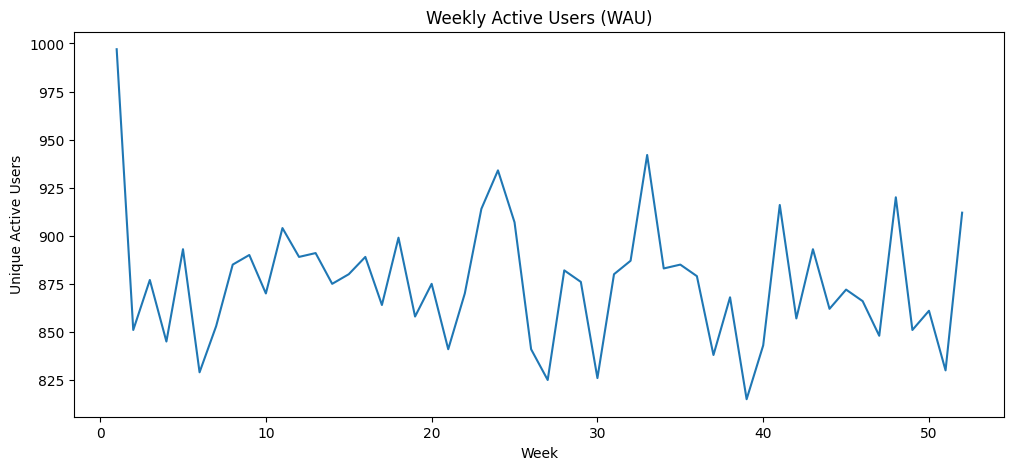

In [56]:
wau.plot(figsize=(12,5))

plt.title("Weekly Active Users (WAU)")
plt.xlabel("Week")
plt.ylabel("Unique Active Users")

plt.show()